In [2]:
%pip install pandas matplotlib seaborn google-generativeai python-dotenv

  Using cached google_generativeai-0.8.6-py3-none-any.whl.metadata (3.9 kB)
  Using cached python_dotenv-1.2.2-py3-none-any.whl.metadata (27 kB)
  Using cached google_ai_generativelanguage-0.6.15-py3-none-any.whl.metadata (5.7 kB)
  Using cached google_api_core-2.32.0-py3-none-any.whl.metadata (3.2 kB)
  Using cached google_api_python_client-2.198.0-py3-none-any.whl.metadata (7.0 kB)
  Using cached tqdm-4.69.0-py3-none-any.whl.metadata (57 kB)
  Using cached protobuf-5.29.6-cp310-abi3-win_amd64.whl.metadata (592 bytes)
  Using cached googleapis_common_protos-1.75.0-py3-none-any.whl.metadata (8.6 kB)
  Using cached requests-2.34.2-py3-none-any.whl.metadata (4.8 kB)
  Using cached pyasn1_modules-0.4.2-py3-none-any.whl.metadata (3.5 kB)
  Using cached httplib2-0.32.0-py3-none-any.whl.metadata (2.2 kB)
  Using cached google_auth_httplib2-0.4.0-py3-none-any.whl.metadata (3.0 kB)
  Using cached uritemplate-4.2.0-py3-none-any.whl.metadata (2.6 kB)
  Using cached annotated_types-0.7.0-py3-none

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
tensorflow 2.21.0 requires protobuf<8.0.0,>=6.31.1, but you have protobuf 5.29.6 which is incompatible.

[notice] A new release of pip is available: 24.3.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [4]:
%pip uninstall -y google-generativeai
%pip install google-genai ipywidgets

Found existing installation: google-generativeai 0.8.6
Uninstalling google-generativeai-0.8.6:
  Successfully uninstalled google-generativeai-0.8.6
Note: you may need to restart the kernel to use updated packages.
  Using cached httpx-0.28.1-py3-none-any.whl.metadata (7.1 kB)
  Using cached distro-1.9.0-py3-none-any.whl.metadata (6.8 kB)
  Using cached sniffio-1.3.1-py3-none-any.whl.metadata (3.9 kB)
  Using cached httpcore-1.0.9-py3-none-any.whl.metadata (21 kB)
   ---------------------------------------- 0.0/1.0 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.0 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.0 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.0 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.0 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.0 MB ? eta -:--:--
   ---------- ----------------------------- 0.3/1.0 MB ? eta -:--:--
   -------------------- ------------------- 0.5/1

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.

[notice] A new release of pip is available: 24.3.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from google import genai
import os
from dotenv import load_dotenv

# Load environment variables
load_dotenv()

# Configure the modern AI client
api_key = os.getenv("GEMINI_API_KEY")
client = genai.Client(api_key=api_key)

print("Environment setup successful! Libraries imported and AI configured.")

Environment setup successful! Libraries imported and AI configured.


In [6]:
import pandas as pd

# 1. Generate a quick sample dataset for testing
test_data = {
    'Month': ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun'],
    'Revenue': [15000, 18000, 17500, 22000, 24000, 21000],
    'Marketing_Spend': [1200, 1500, 1500, 2000, 2100, 1800],
    'Support_Tickets': [45, 50, 42, 60, 65, 55],
    'Missing_Data_Test': [1, 2, None, 4, None, 6] # Simulating real-world messy data
}
df = pd.DataFrame(test_data)
df.to_csv('sample_data.csv', index=False)

# 2. Ingest the Data
# (Later, you can change 'sample_data.csv' to any real dataset you want)
current_df = pd.read_csv('sample_data.csv')

# 3. Create the Profiling Function
def generate_data_profile(dataframe):
    """
    Extracts the core structure, missing values, and statistics of the dataset.
    This string will act as the context window for our AI agent.
    """
    profile = f"Dataset Shape: {dataframe.shape[0]} rows, {dataframe.shape[1]} columns\n\n"
    
    profile += "Columns and Data Types:\n"
    profile += dataframe.dtypes.to_string() + "\n\n"
    
    profile += "Missing Values:\n"
    profile += dataframe.isnull().sum().to_string() + "\n\n"
    
    profile += "Statistical Summary (Numeric Columns):\n"
    profile += dataframe.describe().to_string() + "\n"
    
    return profile

# 4. Test the extraction
data_profile = generate_data_profile(current_df)
print("--- Data Profile Successfully Generated ---\n")
print(data_profile)

--- Data Profile Successfully Generated ---

Dataset Shape: 6 rows, 5 columns

Columns and Data Types:
Month                    str
Revenue                int64
Marketing_Spend        int64
Support_Tickets        int64
Missing_Data_Test    float64

Missing Values:
Month                0
Revenue              0
Marketing_Spend      0
Support_Tickets      0
Missing_Data_Test    2

Statistical Summary (Numeric Columns):
            Revenue  Marketing_Spend  Support_Tickets  Missing_Data_Test
count      6.000000         6.000000         6.000000           4.000000
mean   19583.333333      1683.333333        52.833333           3.250000
std     3322.900340       343.025752         8.841191           2.217356
min    15000.000000      1200.000000        42.000000           1.000000
25%    17625.000000      1500.000000        46.250000           1.750000
50%    19500.000000      1650.000000        52.500000           3.000000
75%    21750.000000      1950.000000        58.750000           4.500

In [11]:
# 1. Define the AI's Persona and Task (The Prompt)
prompt = f"""You are an expert AI Data Analyst. 
I am going to provide you with a statistical profile of a dataset. 
Your job is to analyze this metadata and suggest 3 specific, insightful graphs we should plot to understand this data better.

Rules:
1. Only suggest graphs that make sense for the provided columns and data types.
2. For each graph, explain exactly WHY it is useful for business insights.

Here is the dataset profile:
{data_profile}
"""

print(" Sending data profile to AI... (this might take a few seconds)\n")

# 2. Call the Gemini API using the modern SDK and the latest model
response = client.models.generate_content(
    model='gemini-3.5-flash', 
    contents=prompt
)

# 3. Print the AI's analysis
print("--- AI Visualization Recommendations ---\n")
print(response.text)

 Sending data profile to AI... (this might take a few seconds)

--- AI Visualization Recommendations ---

Based on the statistical profile of your 6-month dataset, we are looking at a classic business performance tracking scenario. We have temporal data (`Month`), financial inflows (`Revenue`), growth investments (`Marketing_Spend`), and customer satisfaction/operational load indicators (`Support_Tickets`). 

*(Note: We will ignore the `Missing_Data_Test` column for these business charts, as it contains 33% missing values and appears to be a placeholder/test variable rather than a core business metric).*

Here are 3 specific, insightful graphs to plot, along with their business rationale:

---

### 1. Dual-Axis Line Chart: Revenue vs. Marketing Spend Over Time
* **X-Axis:** `Month` (ordered chronologically)
* **Left Y-Axis:** `Revenue` (represented as a Bar Chart or Line)
* **Right Y-Axis:** `Marketing_Spend` (represented as a Line)

#### **Why this is useful for business insights:**
*

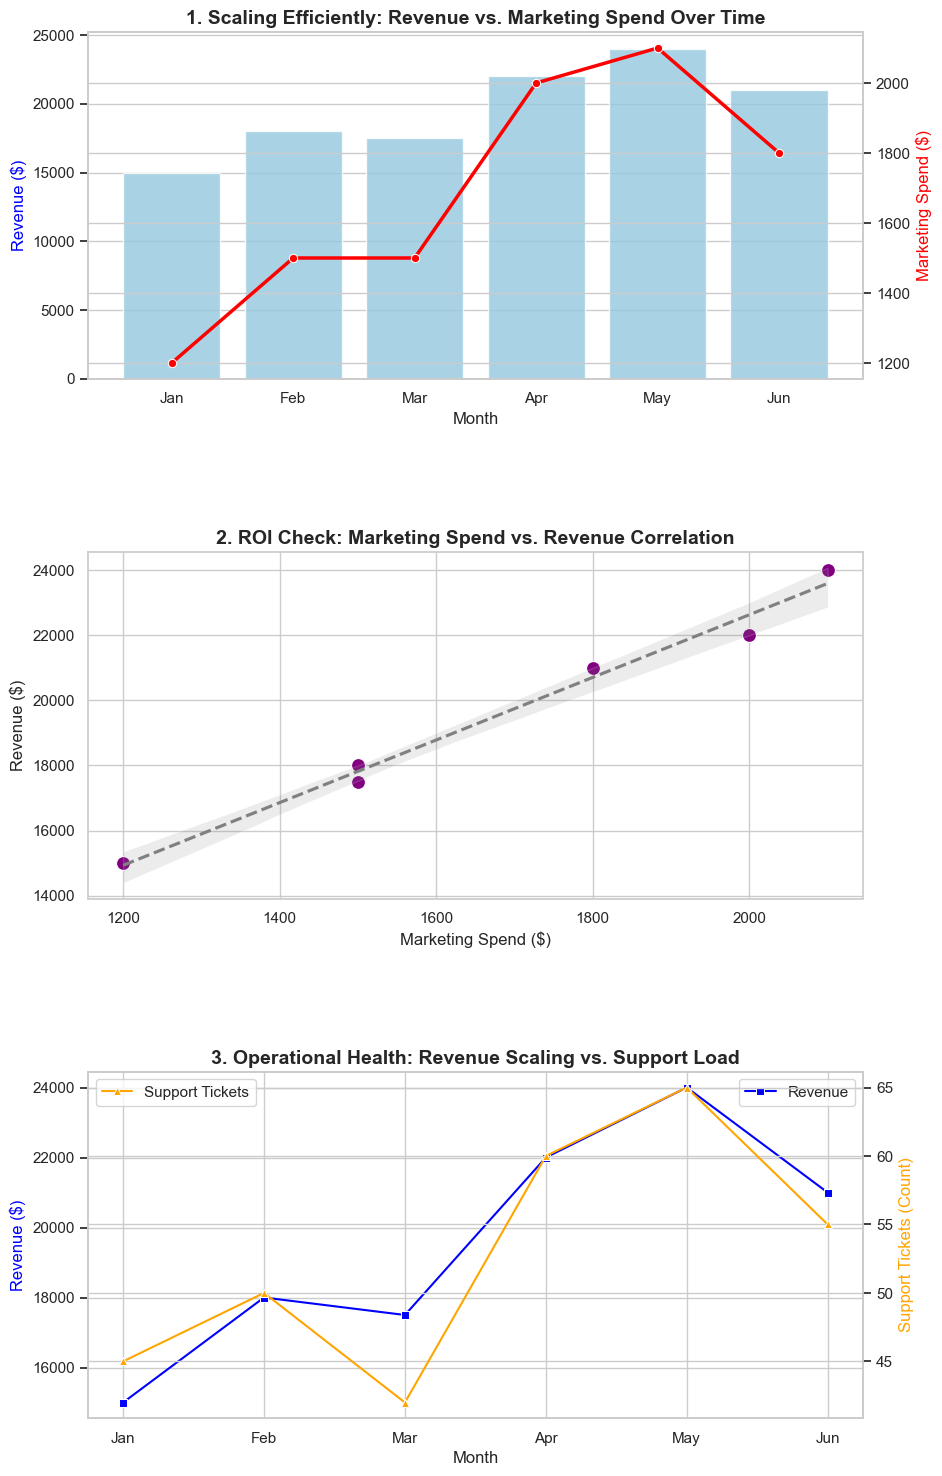

In [12]:
# Set the visual style for our charts to look professional
sns.set_theme(style="whitegrid")

# Create a figure with 3 subplots (one for each graph the AI recommended)
fig, axes = plt.subplots(3, 1, figsize=(10, 18))
plt.subplots_adjust(hspace=0.5) # Add space between the graphs

# --- Graph 1: Dual-Axis Chart (Revenue vs Marketing Spend) ---
ax1 = axes[0]
sns.barplot(data=current_df, x='Month', y='Revenue', ax=ax1, color='skyblue', alpha=0.8)
ax1.set_ylabel('Revenue ($)', color='blue', fontsize=12)
ax1.set_title('1. Scaling Efficiently: Revenue vs. Marketing Spend Over Time', fontsize=14, fontweight='bold')

# Create a second Y-axis that shares the same X-axis for Marketing Spend
ax2 = ax1.twinx()
sns.lineplot(data=current_df, x='Month', y='Marketing_Spend', ax=ax2, color='red', marker='o', linewidth=2.5)
ax2.set_ylabel('Marketing Spend ($)', color='red', fontsize=12)

# --- Graph 2: Scatter Plot (Marketing Spend vs Revenue) ---
sns.scatterplot(data=current_df, x='Marketing_Spend', y='Revenue', ax=axes[1], color='purple', s=100)
sns.regplot(data=current_df, x='Marketing_Spend', y='Revenue', ax=axes[1], scatter=False, color='gray', line_kws={"linestyle":"--"})
axes[1].set_title('2. ROI Check: Marketing Spend vs. Revenue Correlation', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Marketing Spend ($)', fontsize=12)
axes[1].set_ylabel('Revenue ($)', fontsize=12)

# --- Graph 3: Line Chart (Revenue vs Support Tickets) ---
ax3 = axes[2]
sns.lineplot(data=current_df, x='Month', y='Revenue', ax=ax3, color='blue', marker='s', label='Revenue')
ax3.set_ylabel('Revenue ($)', color='blue', fontsize=12)
ax3.set_title('3. Operational Health: Revenue Scaling vs. Support Load', fontsize=14, fontweight='bold')

ax4 = ax3.twinx()
sns.lineplot(data=current_df, x='Month', y='Support_Tickets', ax=ax4, color='orange', marker='^', label='Support Tickets')
ax4.set_ylabel('Support Tickets (Count)', color='orange', fontsize=12)

# Show the final compiled dashboard
plt.show()

In [ ]:
# 1. Define the final reporting prompt
insights_prompt = f"""You are a Senior Business Analyst presenting to the executive team.
You have analyzed the following dataset profile:
{data_profile}

We have just built three visualizations for the dashboard:
1. Revenue vs. Marketing Spend Over Time
2. Marketing Spend vs. Revenue Correlation
3. Revenue Scaling vs. Support Load

Based on the statistical profile and the context of these charts, write a brief, professional "Executive Summary" report. 
Please include:
- 2 Key Observations (What the numbers are telling us)
- 2 Actionable Recommendations (What the business should do next based on the data)

Keep it concise and format it with clear headings and bullet points.
"""

print(" Generating Executive Business Report... \n")

# 2. Call the AI to write the report
final_report = client.models.generate_content(
    model='gemini-3.5-flash',
    contents=insights_prompt
)

# 3. Print the report beautifully
print("     FINAL AI DATA ANALYST REPORT  \n ")

print(final_report.text)